Continuing from makemore 4

* flushed out everything

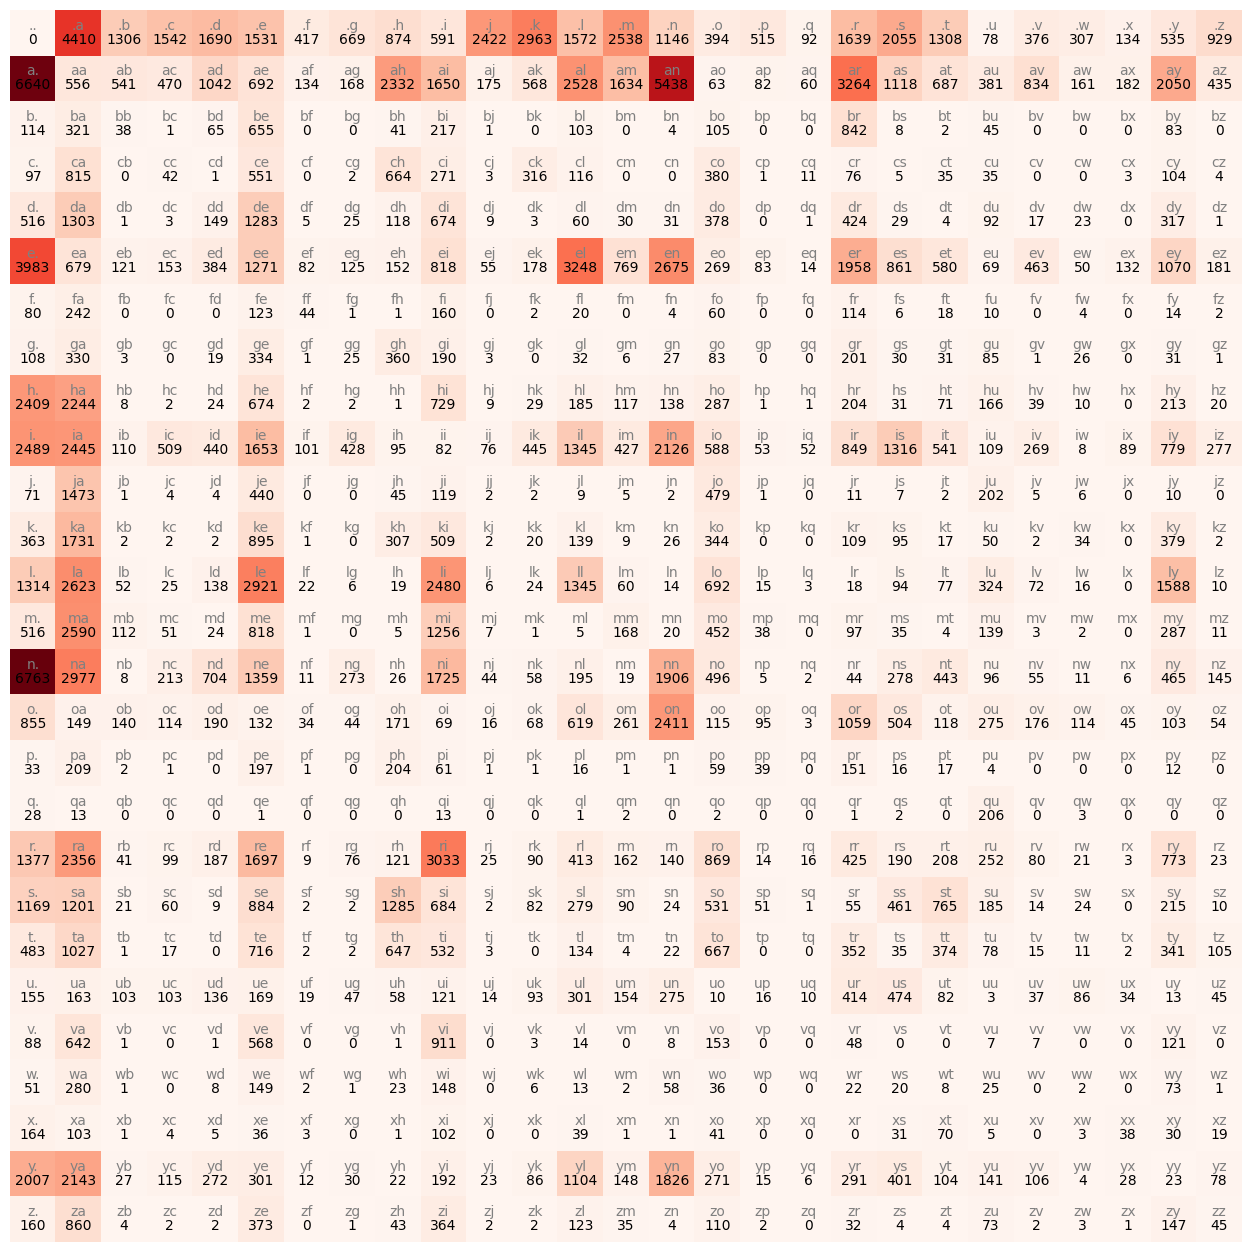

In [2]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

# Read names.txt
words = open('names.txt', 'r').read().splitlines()

# we will need 26 * 26 for all alphabets + 1 for start char
# so 27 * 27
N = torch.zeros((27, 27), dtype = torch.int32)

# a - z
chars = sorted(list(set(''.join(words))))
stoi = {s:i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0

# N will have bigram counter
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]
        N[index1, index2] += 1

itos = {i:s for s, i in stoi.items()}

plt.figure(figsize = (16, 16))
# This prints the whole matrix with color shades (weighed by count)
plt.imshow(N, cmap = 'Reds')

# iterate and add count and bigram
for i in range(27):
    for j in range(27):
        # bigram
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom", color = 'gray')
        # count (N[i, j].item() is count)
        plt.text(j, i, N[i, j].item(), ha = "center", va = "top", color = 'black')
plt.axis('off');

In [3]:
P = (N + 1).float()
P /= P.sum(1, keepdims = True) # will normalize every single row

# sample or infer
g = torch.Generator().manual_seed(912345678) 

for i in range(10):
    out = []
    indexX = 0
    while True:
        p = P[indexX]
        indexX = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
        out.append(itos[indexX])
        if indexX == 0:
            break
    print(''.join(out))

print('-'*30)
# Loss or Negative Log Likelihood
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

nll = -log_likelihood
print(f'{nll/n=}') # Average of NLL (again convenience)

ja.
rik.
s.
a.
xusayremovianeleshay.
jol.
marynga.
ze.
ialetynyn.
gleelin.
------------------------------
nll/n=tensor(2.4544)


# Summary of straightforward way

We trained a respectable bigram character-level language model. And we saw that we both trained the model by looking at the counts of all the bigrams and normalizing the rows to get probability distributions. We saw that we can also then use those parameters of this model

* to perform sampling of new words. So we sample new names according to those distributions.
* And we also saw that we can evaluate the quality of this model.

The quality of this model is summarized in a single number, which is the negative log likelihood. 
The lower this number is, the better the model is because it is giving high probabilities to the actual next characters in all the bigrams in our training set. 

We've arrived at this model explicitly by doing something that felt sensible. We were just performing counts and then we were normalizing those counts.

# Moving on to NN based approach (will arrive at similar Loss)

In [18]:
# create training dataset of all bigrams

xs = [] # inputs
ys = [] # targets
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]
        xs.append(index1)
        ys.append(index2)

xs = torch.tensor(xs) 
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# randomly initialize the network with 27 neurons' weights, each neuron receives 27 inputs
g = torch.Generator().manual_seed(912345678)
W = torch.randn((27, 27), generator = g, requires_grad = True)

number of examples:  228146


In [23]:
import torch.nn.functional as F

learning_rate = -50

# gradient descent
for k in range(25):
    # forward pass
    xenc = F.one_hot(xs, num_classes = 27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, or fake counts
    probs = counts / counts.sum(1, keepdims = True) # probabilities from fake counts
    loss = -probs[torch.arange(num), ys].log().mean()
    print(f'{loss.item()=}')

    # backward pass
    W.grad = None # set the gradient to zero 
    loss.backward() # something magical happened. 

    # updates the tensor
    W.data += learning_rate * W.grad

loss.item()=2.5029850006103516
loss.item()=2.5018601417541504
loss.item()=2.500779151916504
loss.item()=2.4997403621673584
loss.item()=2.4987409114837646
loss.item()=2.4977781772613525
loss.item()=2.4968512058258057
loss.item()=2.495957136154175
loss.item()=2.4950945377349854
loss.item()=2.4942619800567627
loss.item()=2.493457555770874
loss.item()=2.492680311203003
loss.item()=2.491929054260254
loss.item()=2.491201877593994
loss.item()=2.4904983043670654
loss.item()=2.4898173809051514
loss.item()=2.4891574382781982
loss.item()=2.488518238067627
loss.item()=2.487898349761963
loss.item()=2.487297534942627
loss.item()=2.4867146015167236
loss.item()=2.4861485958099365
loss.item()=2.4855997562408447
loss.item()=2.4850666522979736
loss.item()=2.484548568725586


This loss looks basically same as counting (for simple setting like bigram, explicity counting was working.). Fundamentally it should be, because we are not taking any additional information.

In NN, we are letting loss guide us to find those correct W.exp or counts. Instead of doing it explicitly by counting and normalizing.
From counting array above is same as
```python
# From NN
logits = xenc @ W # predict log-counts
```

Because we were only considering last 1 char, so we could keep it in a matrix and visualize.
But if we move to last N char, we cannot visualize it easily by keeping it in table.

But with gradient based approach, it is more flexible. 
We can make it more complex, like read multiple previous characters.
NN is more scalable.

For more complex advancements in future weeks, nothing will change except how logits are built.

---

Smoothing also exists for NN. It is called "Regularization".
In NN, we are assigning W with random numbers. If we assign all of W as 0.
logits which is W.exp, will all be 1. 

We can add this to loss. This will be "Regularization loss"

More on this in last 6 minutes of the video: https://youtu.be/PaCmpygFfXo?si=Nsq4XdLojlrDwnj8&t=6671

In [25]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(912345678)

for i in range(10):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE with counting:
    # p = P[ix]
    # ----------
    # NOW with NN:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

ja.
rik.
s.
afxusayremovianeleshay.
jal.
maryngqrze.
ialetynyn.
gleelin.
atran.
kh.
